In [17]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [18]:
from langchain_core.messages import AIMessage,HumanMessage
from pprint import pprint

In [19]:
messages=[AIMessage(content=f"Please tell me how can I help",name="LLModel")]
messages.append(HumanMessage(content=f"I want to learn coding",name="Nico"))
messages.append(AIMessage(content=f"Wich programming language you want to learn",name="LLModel"))
messages.append(HumanMessage(content=f"I want to learn Python programming language",name="Nico"))

for message in messages:
    message.pretty_print()


================================== Ai Message ==================================
Name: LLModel

Please tell me how can I help
================================ Human Message =================================
Name: Nico

I want to learn coding
================================== Ai Message ==================================
Name: LLModel

Wich programming language you want to learn
================================ Human Message =================================
Name: Nico

I want to learn Python programming language


# Chat Models

In [20]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="llama-3.1-8b-instant")
result=llm_groq.invoke(messages)

In [21]:
result

AIMessage(content='Python is a great language to start with, known for its simplicity and versatility. Here\'s a step-by-step guide to help you get started:\n\n**1. Install Python:**\nDownload and install the latest version of Python from the official Python website: <https://www.python.org/downloads/>\n\n**2. Choose a Text Editor or IDE:**\nYou\'ll need a text editor or Integrated Development Environment (IDE) to write and run your Python code. Some popular options include:\n\t* PyCharm (free community edition)\n\t* Visual Studio Code (free)\n\t* Sublime Text (free trial, then paid)\n\t* Notepad++ (free)\n\n**3. Learn the Basics:**\nStart with basic syntax, data types, variables, operators, loops, and control structures. You can find many online resources, such as:\n\t* Codecademy\'s Python course (interactive coding environment)\n\t* Python.org\'s official tutorial (comprehensive and free)\n\t* W3Schools\' Python tutorial (concise and easy to understand)\n\n**4. Practice, Practice, P

In [22]:
print(result.content)

Python is a great language to start with, known for its simplicity and versatility. Here's a step-by-step guide to help you get started:

**1. Install Python:**
Download and install the latest version of Python from the official Python website: <https://www.python.org/downloads/>

**2. Choose a Text Editor or IDE:**
You'll need a text editor or Integrated Development Environment (IDE) to write and run your Python code. Some popular options include:
	* PyCharm (free community edition)
	* Visual Studio Code (free)
	* Sublime Text (free trial, then paid)
	* Notepad++ (free)

**3. Learn the Basics:**
Start with basic syntax, data types, variables, operators, loops, and control structures. You can find many online resources, such as:
	* Codecademy's Python course (interactive coding environment)
	* Python.org's official tutorial (comprehensive and free)
	* W3Schools' Python tutorial (concise and easy to understand)

**4. Practice, Practice, Practice:**
Practice writing Python code through:


# Tools

In [39]:
def add(a:int,b:int)->int:
    """ Add a and b
    Args:
    a (int): first int
    b (int): second int
    
    Return:
    int
    """
    return a+b

In [24]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="llama-3.1-8b-instant")

# Binding tool with llm

llm_with_tools=llm_groq.bind_tools([add])

tool_call=llm_with_tools.invoke([HumanMessage(content=f"What is 2 plus 2?",name="Nico")])

In [25]:
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'jga6d8s2k',
  'type': 'tool_call'}]

## Using messages as state

In [26]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage # 

class State(TypedDict): # Création d'un dictionnaire State
    messages:list[AnyMessage] # message -> clé / liste de message Langchain

## Reducer

In [ ]:
# State of the class

from langgraph.graph.message import add_messages # Pour fusionner 2 listes de messages
from typing import Annotated

class State(TypedDict): 
    messages:Annotated[list[AnyMessage],add_messages]
    # Le champ messages est une liste de messages, et quand plusieurs nodes retournent des messages, utilise la fonction add_messages pour les fusionner. Sans reducer, une nouvelle valeur remplace l'ancienne

## Reducer with add_messages

In [28]:
initial_messages=[AIMessage(content=f"Please tell me how can I help",name="LLModel")]
initial_messages.append(HumanMessage(content=f"I want to learn coding",name="Nico"))
initial_messages

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLModel', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Nico')]

In [29]:
ai_message=AIMessage(content=f"Wich programming language you want to learn",name="LLModel")
ai_message

AIMessage(content='Wich programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLModel', tool_calls=[], invalid_tool_calls=[])

In [30]:
add_messages(initial_messages,ai_message)

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLModel', id='3e06dc03-48f6-41b9-8c3d-f7a761a7184d', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Nico', id='7fdd3e43-aa05-4d1e-958a-d992db5aa27f'),
 AIMessage(content='Wich programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLModel', id='8a26284a-4d91-4642-bafd-95396680b0fd', tool_calls=[], invalid_tool_calls=[])]

In [31]:
# Chatbot node functionality

def llm_tool(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

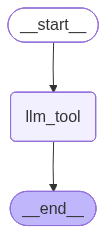

In [32]:
from IPython.display import Image, display
from langgraph.graph import StateGraph,START,END

builder=StateGraph(State)

builder.add_node("llm_tool",llm_tool)

builder.add_edge(START,"llm_tool")
builder.add_edge("llm_tool",END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [33]:
messages = graph.invoke({"messages":"What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (6dq8e28jq)
 Call ID: 6dq8e28jq
  Args:
    a: 2
    b: 2


### Le LLM connait la tool : llm_with_tools=llm_groq.bind_tools([add]), mais ne l'execute pas. Il execute l'outil ensuite avec ToolNode(tools)

In [40]:
tools=[add]

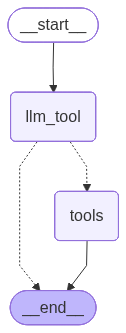

In [ ]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

builder = StateGraph(State)

builder.add_node("llm_tool",llm_tool)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # Si le dernier message (result) de l'assistant est un appel d'outil -> conditions de l'outils sont transmises à l'outils
    # Si le dernier message (result) de l'assisdtant n'est pas un appel d'outil -> tools_condition transmis à END
    tools_condition # retounne soit tools soit END. Même si le node tools n est pas dans add_conditional_edges, tools_condition retourne automatiquement tools
)

builder.add_edge("tools",END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [43]:
messages = graph.invoke({"messages":"What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (0jwsa8rev)
 Call ID: 0jwsa8rev
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4


In [44]:
messages = graph.invoke({"messages":"What is machien learning?"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is machien learning?
================================== Ai Message ==================================

<brave_search={"title":"Machine Learning", "description":"Machine learning is a subset of artificial intelligence (AI) that involves the use of algorithms and statistical models to enable machines to learn from data, without being explicitly programmed."}</brave_search>
